# Apple Quality ML 🍎

### Machine Learning with python to identify the quality of an apple!

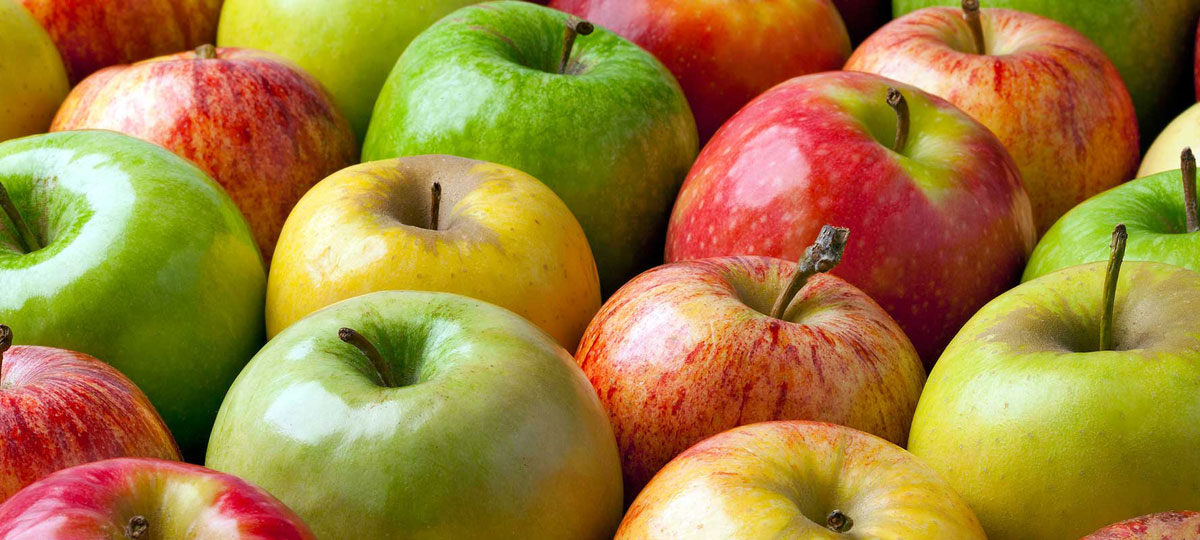

#### 1. Creating a Machine Learning

1️⃣ Import necessary **libraries** to work with ML

In [106]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

2️⃣ Split the data with **X** (data) and **Y** (target) and **TRAIN** (70%) and **TEST** (30%)



In [82]:
apple_data = np.genfromtxt('apple_quality.csv', delimiter=',', skip_header=1, skip_footer=1, dtype=str)
apple_data = apple_data[:, 1:]
X = apple_data[:, :-1].astype(float)
y = apple_data[:,-1]

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

3️⃣ Draw the graphs to compare **TWO COLUMNS** of the dataset.



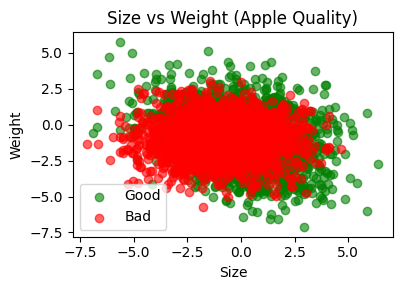

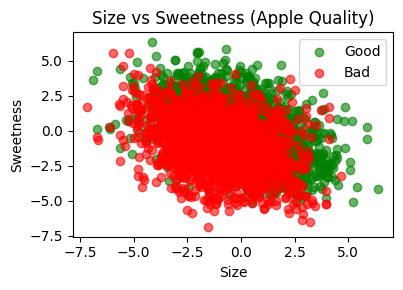

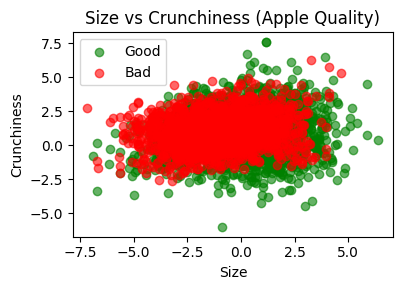

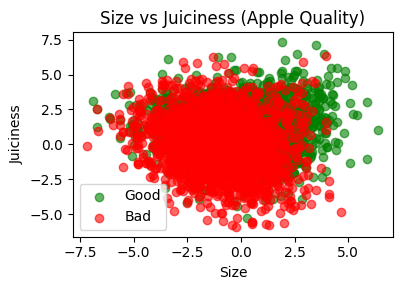

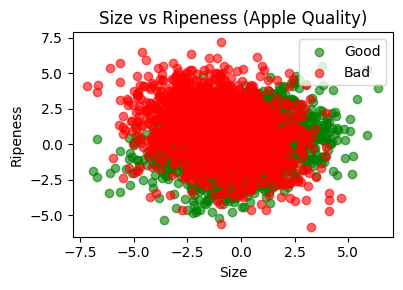

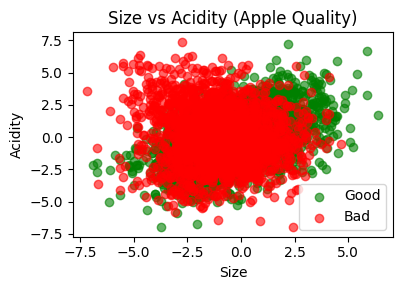

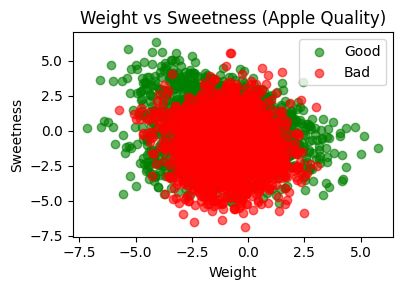

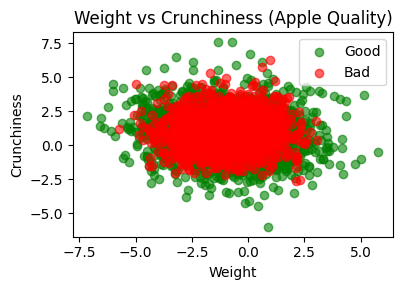

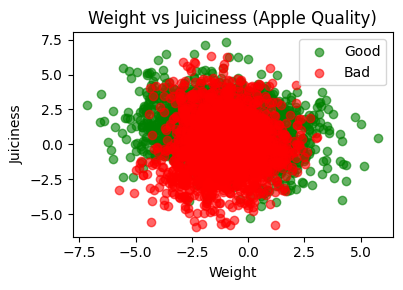

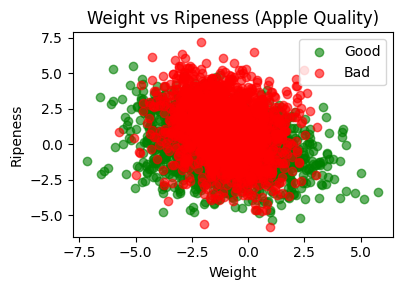

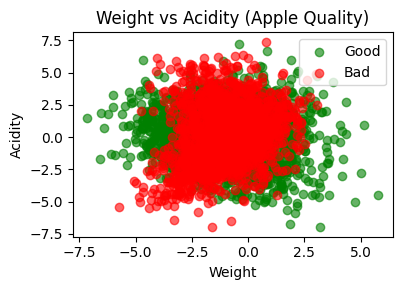

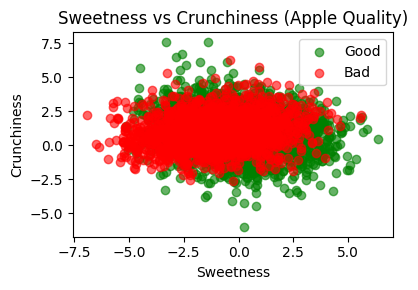

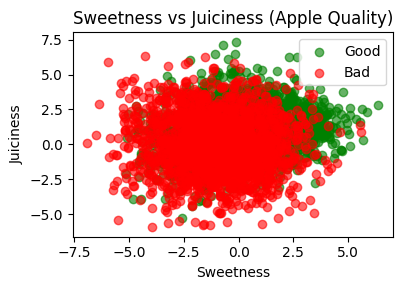

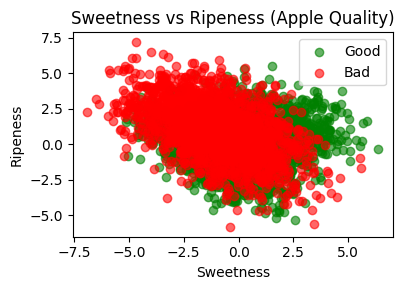

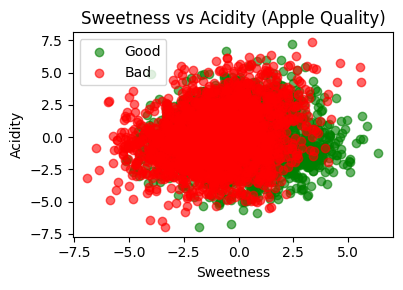

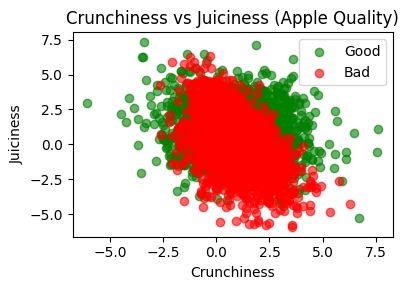

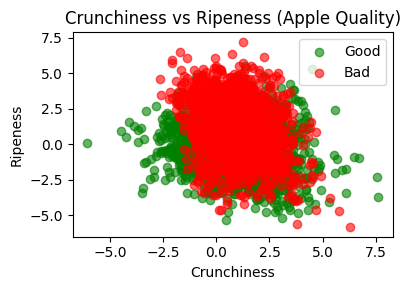

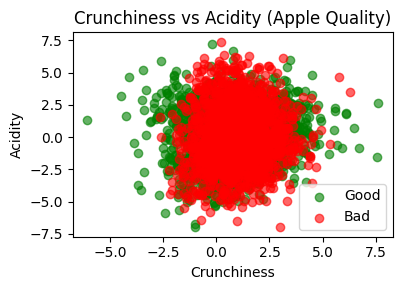

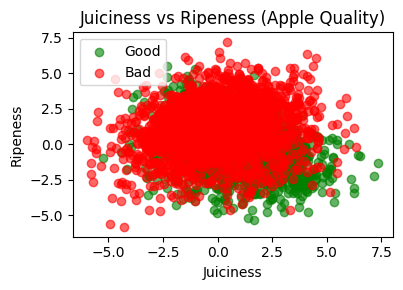

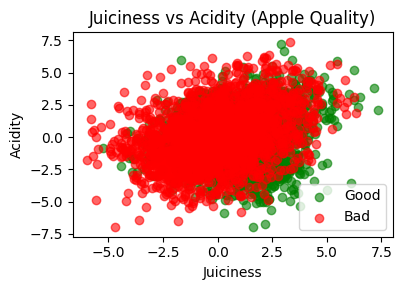

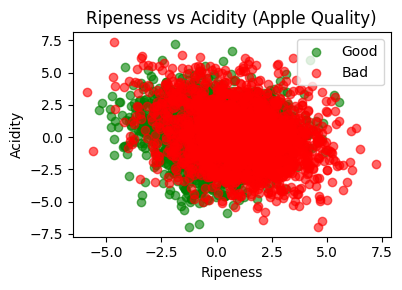

In [124]:
def plot(col_x, col_y):
    good_mask = (y == 'good')
    bad_mask = (y == 'bad')

    plt.figure(figsize=(4, 3))
    
    plt.scatter(X[good_mask, col_x], X[good_mask, col_y],
                c='green', label='Good', alpha=0.6)
    plt.scatter(X[bad_mask, col_x], X[bad_mask, col_y],
                c='red', label='Bad', alpha=0.6)

    plt.xlabel(columns[col_x])
    plt.ylabel(columns[col_y])
    plt.legend()
    plt.title(f'{columns[col_x]} vs {columns[col_y]} (Apple Quality)')
    plt.tight_layout()
    plt.show()

n_cols = X.shape[1]

for i in range(n_cols):
    for j in range(i + 1, n_cols):
        plot(i, j)

4️⃣ **TRAIN** the ML, **PREDICT** and **SHOW** the DecisionTree!



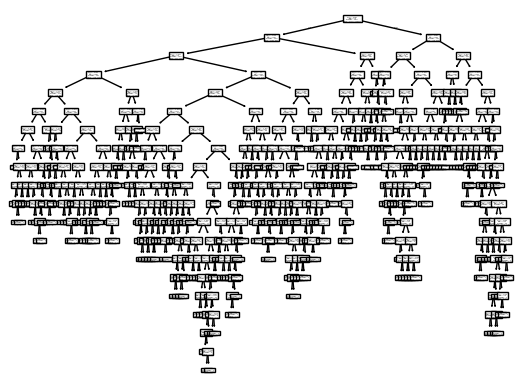

In [125]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
plt.figure()
plot_tree(clf)
plt.show()

5️⃣ Draw the **CONFUSIONMATRIX** and the **ACCURACY** to see the results clearly.


0.8108333333333333

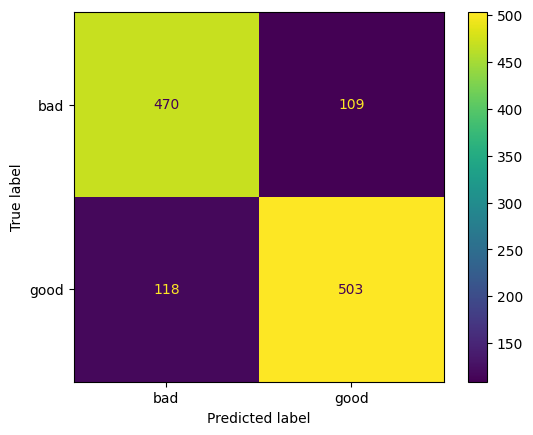

In [126]:
ConfusionMatrixDisplay.from_predictions(y_test,prediction)
accuracy_score(y_test, prediction)

#### 2. KBest and testing with different values!


In [128]:
X.shape
print(X.shape)
selector = SelectKBest(k=3)
X_new = selector.fit_transform(X, y)
print(X_new.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

selected_mask = selector.get_support() #print the features that KBest select
print(selected_mask)

(4000, 7)
(4000, 3)
[False False  True False  True  True False]


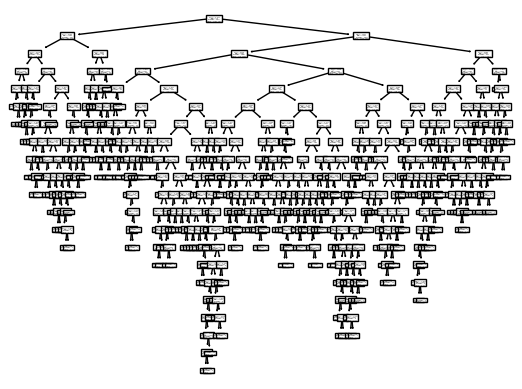

In [94]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
plt.figure()
plot_tree(clf)
plt.show()

0.8083333333333333

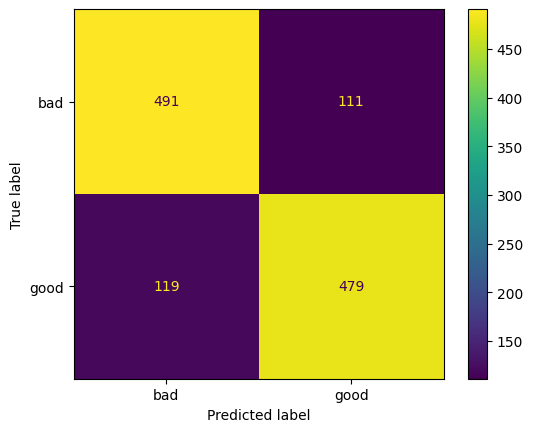

In [95]:
ConfusionMatrixDisplay.from_predictions(y_test,prediction)
accuracy_score(y_test, prediction)